2025-07-10 15:45:04,627 - INFO - LymphNodeMerger initialized with parameters:
2025-07-10 15:45:04,628 - INFO -   Distance threshold: 2.0 mm
2025-07-10 15:45:04,629 - INFO -   Contact area threshold: 10.0 mm²
2025-07-10 15:45:04,629 - INFO -   Intensity difference threshold: 0.2
2025-07-10 15:45:04,630 - INFO -   Dilation radius: 1 voxels
2025-07-10 15:45:04,631 - INFO - Loading MRI image from data/raw/images/1095-T2_FS_TRA+301.nii.gz
2025-07-10 15:45:05,016 - INFO - Loading annotation image from data/raw/labels/1095-T2_FS_TRA+301.nii.gz
2025-07-10 15:45:05,066 - INFO - Size match: True, Spacing match: True, Origin match: True
2025-07-10 15:45:05,068 - INFO - Image spacing: (0.44920000433921814, 0.44920000433921814, 4.0)
2025-07-10 15:45:05,219 - INFO - Found 7 lymph node annotations with labels: [1 2 3 4 5 6 7]
2025-07-10 15:45:05,221 - INFO - Creating mask for node 1
2025-07-10 15:45:05,320 - INFO -   Node 1 stats: {'mean_intensity': np.float64(49.50679422997173), 'std_intensity': np.

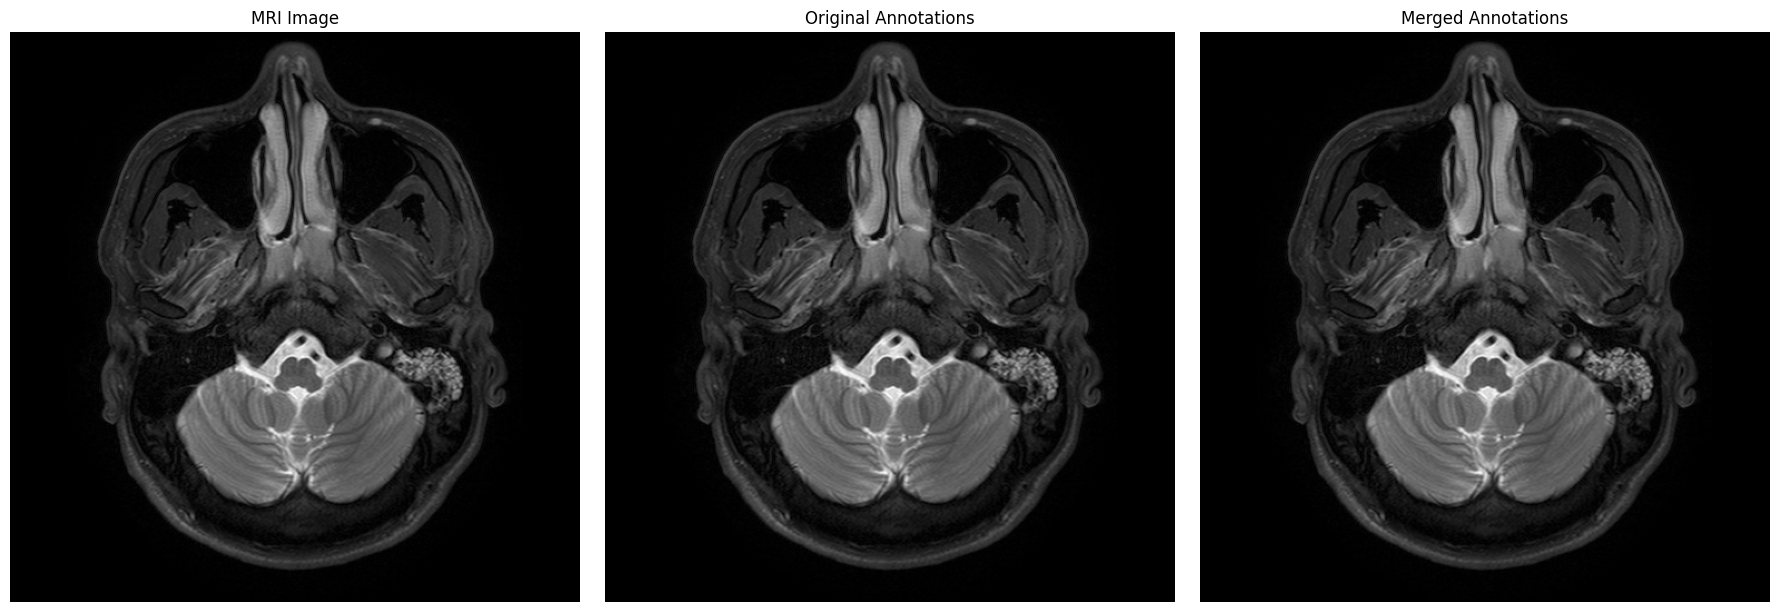

2025-07-10 15:45:34,457 - INFO - Saving merged annotations to test.nii.gz


In [1]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import ndimage
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class LymphNodeMerger:
    def __init__(self, mri_path, annotation_path, 
                 distance_threshold=2.0,  # in mm
                 contact_area_threshold=10.0,  # in mm²
                 intensity_diff_threshold=0.2,  # relative threshold
                 dilation_radius=1):  # voxels
        """
        Initialize the LymphNodeMerger with the given parameters.
        
        Parameters:
        -----------
        mri_path : str
            Path to the MRI image in NIFTI format
        annotation_path : str
            Path to the annotation image in NIFTI format
        distance_threshold : float
            Maximum distance (in mm) between nodes to be considered for merging
        contact_area_threshold : float
            Minimum contact surface area (in mm²) required for merging
        intensity_diff_threshold : float
            Maximum relative intensity difference allowed between nodes and contact region
        dilation_radius : int
            Radius for dilation operation in voxels
        """
        self.mri_path = mri_path
        self.annotation_path = annotation_path
        self.distance_threshold = distance_threshold
        self.contact_area_threshold = contact_area_threshold
        self.intensity_diff_threshold = intensity_diff_threshold
        self.dilation_radius = dilation_radius
        
        self.mri_image = None
        self.annotation_image = None
        self.spacing = None
        self.node_labels = None
        self.node_masks = {}
        self.node_stats = {}
        self.adjacency_graph = None
        
        logger.info("LymphNodeMerger initialized with parameters:")
        logger.info(f"  Distance threshold: {distance_threshold} mm")
        logger.info(f"  Contact area threshold: {contact_area_threshold} mm²")
        logger.info(f"  Intensity difference threshold: {intensity_diff_threshold}")
        logger.info(f"  Dilation radius: {dilation_radius} voxels")
        
    def load_data(self):
        """Load MRI and annotation data."""
        logger.info(f"Loading MRI image from {self.mri_path}")
        self.mri_image = sitk.ReadImage(self.mri_path)
        
        logger.info(f"Loading annotation image from {self.annotation_path}")
        self.annotation_image = sitk.ReadImage(self.annotation_path)
        
        # Ensure same coordinate system
        if not self._check_coordinate_match():
            logger.warning("MRI and annotation images might not be in the same coordinate system!")
        
        self.spacing = self.mri_image.GetSpacing()
        logger.info(f"Image spacing: {self.spacing}")
        
        # Extract node labels
        np_annotation = sitk.GetArrayFromImage(self.annotation_image)
        self.node_labels = np.unique(np_annotation)
        self.node_labels = self.node_labels[self.node_labels > 0]  # Remove background
        
        logger.info(f"Found {len(self.node_labels)} lymph node annotations with labels: {self.node_labels}")
        
        # Create individual masks for each node
        self._create_node_masks()
        
        return self
    
    def _check_coordinate_match(self):
        """Check if MRI and annotation images have matching coordinate systems."""
        mri_size = self.mri_image.GetSize()
        anno_size = self.annotation_image.GetSize()
        mri_spacing = self.mri_image.GetSpacing()
        anno_spacing = self.annotation_image.GetSpacing()
        mri_origin = self.mri_image.GetOrigin()
        anno_origin = self.annotation_image.GetOrigin()
        
        size_match = mri_size == anno_size
        spacing_match = all(abs(m - a) < 1e-3 for m, a in zip(mri_spacing, anno_spacing))
        origin_match = all(abs(m - a) < 1e-3 for m, a in zip(mri_origin, anno_origin))
        
        logger.info(f"Size match: {size_match}, Spacing match: {spacing_match}, Origin match: {origin_match}")
        
        return size_match and spacing_match and origin_match
    
    def _create_node_masks(self):
        """Create binary masks for each lymph node."""
        for label in self.node_labels:
            logger.info(f"Creating mask for node {label}")
            
            # Create binary mask for this node
            node_mask = sitk.Equal(self.annotation_image, int(label))
            self.node_masks[label] = node_mask
            
            # Calculate basic statistics for this node
            np_mri = sitk.GetArrayFromImage(self.mri_image)
            np_mask = sitk.GetArrayFromImage(node_mask)
            node_voxels = np_mri[np_mask > 0]
            
            if len(node_voxels) > 0:
                self.node_stats[label] = {
                    'mean_intensity': np.mean(node_voxels),
                    'std_intensity': np.std(node_voxels),
                    'volume_mm3': np.sum(np_mask) * np.prod(self.spacing),
                    'voxel_count': np.sum(np_mask)
                }
                logger.info(f"  Node {label} stats: {self.node_stats[label]}")
            else:
                logger.warning(f"  Node {label} has no voxels!")
    
    def analyze_node_pairs(self):
        """Analyze all pairs of nodes to determine potential merges."""
        logger.info("Starting node pair analysis")
        
        # Create a graph where nodes are lymph nodes and edges represent potential merges
        self.adjacency_graph = nx.Graph()
        for label in self.node_labels:
            self.adjacency_graph.add_node(label)
        
        # Analyze all unordered pairs
        node_pairs = [(a, b) for i, a in enumerate(self.node_labels) 
                     for b in self.node_labels[i+1:]]
        
        logger.info(f"Analyzing {len(node_pairs)} node pairs")
        
        for node_a, node_b in node_pairs:
            logger.info(f"Analyzing node pair ({node_a}, {node_b})")
            
            # Check minimum distance
            min_distance = self._calculate_min_distance(node_a, node_b)
            logger.info(f"  Minimum distance: {min_distance} mm")
            
            # Only proceed if distance is within threshold
            if min_distance > self.distance_threshold:
                logger.info("  Distance exceeds threshold, skipping further analysis")
                continue
            
            # Calculate contact surface area after dilation
            contact_area, contact_mask = self._calculate_contact_area(node_a, node_b)
            logger.info(f"  Contact surface area: {contact_area} mm²")
            
            if contact_area < self.contact_area_threshold:
                logger.info("  Contact area below threshold, skipping further analysis")
                continue
            
            # Check intensity similarity
            is_similar, similarity_score = self._check_intensity_similarity(node_a, node_b, contact_mask)
            logger.info(f"  Intensity similarity: {is_similar} (score: {similarity_score:.3f})")
            
            if is_similar:
                logger.info(f"  Adding edge between nodes {node_a} and {node_b}")
                self.adjacency_graph.add_edge(node_a, node_b, 
                                             distance=min_distance,
                                             contact_area=contact_area,
                                             similarity=similarity_score)
        
        return self
    
    def _calculate_min_distance(self, node_a, node_b):
        """Calculate minimum surface-to-surface distance between two nodes."""
        # Convert masks to numpy arrays
        mask_a = sitk.GetArrayFromImage(self.node_masks[node_a])
        mask_b = sitk.GetArrayFromImage(self.node_masks[node_b])
        
        # Calculate distance transform for both masks
        dist_a = ndimage.distance_transform_edt(~mask_a, sampling=self.spacing)
        dist_b = ndimage.distance_transform_edt(~mask_b, sampling=self.spacing)
        
        # Minimum distance from A to B
        min_dist_a_to_b = np.min(dist_a[mask_b > 0]) if np.any(mask_b) else np.inf
        
        # Minimum distance from B to A
        min_dist_b_to_a = np.min(dist_b[mask_a > 0]) if np.any(mask_a) else np.inf
        
        # Return the minimum of the two distances
        return min(min_dist_a_to_b, min_dist_b_to_a)
    
    def _calculate_contact_area(self, node_a, node_b):
        """Calculate contact surface area between two nodes after dilation."""
        # Dilate both masks
        dilated_a = self._dilate_mask(self.node_masks[node_a])
        dilated_b = self._dilate_mask(self.node_masks[node_b])
        
        # Find intersection of dilated masks
        intersection = sitk.And(dilated_a, dilated_b)
        
        # Remove original masks from intersection to get only the contact region
        original_a = self.node_masks[node_a]
        original_b = self.node_masks[node_b]
        contact_region = sitk.And(intersection, sitk.Not(sitk.Or(original_a, original_b)))
        
        # Calculate surface area
        np_contact = sitk.GetArrayFromImage(contact_region)
        voxel_volume = np.prod(self.spacing)
        contact_voxels = np.sum(np_contact)
        
        # Estimate surface area - this is an approximation
        # For a more accurate calculation, we would need to count boundary voxels
        contact_area = contact_voxels * voxel_volume**(2/3)
        
        return contact_area, contact_region
    
    def _dilate_mask(self, mask):
        """Dilate a binary mask."""
        dilate_filter = sitk.BinaryDilateImageFilter()
        dilate_filter.SetKernelRadius(self.dilation_radius)
        dilate_filter.SetForegroundValue(1)
        return dilate_filter.Execute(mask)
    
    def _check_intensity_similarity(self, node_a, node_b, contact_mask):
        """Check if the intensity in the contact region is similar to the nodes."""
        # Get intensity values
        np_mri = sitk.GetArrayFromImage(self.mri_image)
        np_contact = sitk.GetArrayFromImage(contact_mask)
        
        # Extract intensities for each region
        if np.sum(np_contact) == 0:
            logger.warning("  Contact region is empty")
            return False, 0
            
        contact_intensities = np_mri[np_contact > 0]
        mean_contact = np.mean(contact_intensities)
        
        # Compare with node intensities
        mean_a = self.node_stats[node_a]['mean_intensity']
        mean_b = self.node_stats[node_b]['mean_intensity']
        
        # Calculate weighted average of node intensities
        weighted_mean = (mean_a * self.node_stats[node_a]['voxel_count'] + 
                         mean_b * self.node_stats[node_b]['voxel_count']) / \
                        (self.node_stats[node_a]['voxel_count'] + 
                         self.node_stats[node_b]['voxel_count'])
        
        # Calculate relative difference
        rel_diff = abs(mean_contact - weighted_mean) / weighted_mean
        
        # Check if intensity difference is within threshold
        is_similar = rel_diff <= self.intensity_diff_threshold
        
        return is_similar, 1 - rel_diff  # Convert to similarity score (0-1)
    
    def identify_matted_nodes(self):
        """Identify groups of matted nodes using connected components."""
        if self.adjacency_graph is None:
            logger.error("Node pair analysis has not been run yet!")
            return None
        
        # Find connected components in the adjacency graph
        connected_components = list(nx.connected_components(self.adjacency_graph))
        
        logger.info(f"Found {len(connected_components)} matted node groups:")
        for i, component in enumerate(connected_components):
            logger.info(f"  Group {i+1}: {component}")
        
        return connected_components
    
    def merge_annotations(self):
        """Merge annotations based on identified matted node groups."""
        matted_groups = self.identify_matted_nodes()
        
        if not matted_groups:
            logger.info("No matted node groups to merge")
            return self.annotation_image
        
        # Create a new label image
        merged_annotation = sitk.Image(self.annotation_image.GetSize(),
                                      self.annotation_image.GetPixelID())
        merged_annotation.CopyInformation(self.annotation_image)
        
        # Copy the original annotation first
        merged_annotation = sitk.Cast(self.annotation_image, merged_annotation.GetPixelID())
        
        # Process each matted group
        for i, group in enumerate(matted_groups):
            if len(group) <= 1:
                logger.info(f"Skipping group {i+1} as it contains only one node")
                continue
                
            logger.info(f"Merging group {i+1}: {group}")
            
            # Create a new label for this group (use the minimum label in the group)
            new_label = min(group)
            
            # Create a mask for the entire group
            group_mask = sitk.Image(self.annotation_image.GetSize(), sitk.sitkUInt8)
            group_mask.CopyInformation(self.annotation_image)
            
            # Union all node masks in this group
            for node_label in group:
                if node_label != new_label:  # Skip the new label as it will stay the same
                    # Create a temporary image for this operation
                    temp_mask = sitk.Equal(self.annotation_image, int(node_label))
                    group_mask = sitk.Or(group_mask, temp_mask)
                    
                    # Remove the original node from the merged annotation
                    merged_annotation = sitk.Cast(
                        sitk.Where(temp_mask, 
                                  sitk.Cast(sitk.Image(temp_mask.GetSize(), 
                                                     merged_annotation.GetPixelID()), 
                                          merged_annotation.GetPixelID()), 
                                  merged_annotation),
                        merged_annotation.GetPixelID()
                    )
            
            # Add the merged group to the new annotation with the new label
            merged_annotation = sitk.Cast(
                sitk.Where(group_mask, 
                          sitk.Cast(sitk.Image(group_mask.GetSize(), 
                                             merged_annotation.GetPixelID()) + new_label,
                                  merged_annotation.GetPixelID()),
                          merged_annotation),
                merged_annotation.GetPixelID()
            )
        
        logger.info("Annotation merging completed")
        return merged_annotation
    
    def visualize_results(self, slice_idx=None):
        """Visualize the original and merged annotations."""
        if not hasattr(self, 'merged_annotation'):
            logger.info("Running merge_annotations first")
            self.merged_annotation = self.merge_annotations()
        
        # Get numpy arrays for visualization
        np_mri = sitk.GetArrayFromImage(self.mri_image)
        np_original = sitk.GetArrayFromImage(self.annotation_image)
        np_merged = sitk.GetArrayFromImage(self.merged_annotation)
        
        # If slice_idx is not provided, use the middle slice
        if slice_idx is None:
            slice_idx = np_mri.shape[0] // 2
            
        # Check slice index
        if slice_idx < 0 or slice_idx >= np_mri.shape[0]:
            logger.error(f"Invalid slice index: {slice_idx}")
            slice_idx = np_mri.shape[0] // 2
            
        logger.info(f"Visualizing results for slice {slice_idx}")
        
        # Create figure
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # MRI image
        axes[0].imshow(np_mri[slice_idx], cmap='gray')
        axes[0].set_title('MRI Image')
        axes[0].axis('off')
        
        # Original annotation
        axes[1].imshow(np_mri[slice_idx], cmap='gray')
        mask = np_original[slice_idx] > 0
        overlay = np.zeros((*np_original[slice_idx].shape, 4))
        for label in self.node_labels:
            color = plt.cm.tab10(label % 10)
            label_mask = np_original[slice_idx] == label
            overlay[label_mask] = color
        overlay[..., 3] = 0.5 * mask  # Transparency
        axes[1].imshow(overlay)
        axes[1].set_title('Original Annotations')
        axes[1].axis('off')
        
        # Merged annotation
        axes[2].imshow(np_mri[slice_idx], cmap='gray')
        mask = np_merged[slice_idx] > 0
        overlay = np.zeros((*np_merged[slice_idx].shape, 4))
        unique_labels = np.unique(np_merged[slice_idx])
        unique_labels = unique_labels[unique_labels > 0]
        for label in unique_labels:
            color = plt.cm.tab10(label % 10)
            label_mask = np_merged[slice_idx] == label
            overlay[label_mask] = color
        overlay[..., 3] = 0.5 * mask  # Transparency
        axes[2].imshow(overlay)
        axes[2].set_title('Merged Annotations')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # If there are matted groups, visualize the graph
        if hasattr(self, 'adjacency_graph') and len(self.adjacency_graph.edges) > 0:
            plt.figure(figsize=(10, 8))
            pos = nx.spring_layout(self.adjacency_graph)
            
            # Draw nodes
            nx.draw_networkx_nodes(self.adjacency_graph, pos, 
                                  node_color='lightblue', 
                                  node_size=500)
            
            # Draw edges with weights based on similarity
            edge_weights = [self.adjacency_graph[u][v].get('similarity', 0.5) 
                           for u, v in self.adjacency_graph.edges()]
            
            nx.draw_networkx_edges(self.adjacency_graph, pos, 
                                  width=[w*3 for w in edge_weights],
                                  alpha=0.7)
            
            # Draw labels
            nx.draw_networkx_labels(self.adjacency_graph, pos, 
                                   font_size=12, 
                                   font_family='sans-serif')
            
            plt.title("Node Adjacency Graph (Edge Width = Similarity)")
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        
        return self
    
    def save_results(self, output_path):
        """Save the merged annotation to file."""
        if not hasattr(self, 'merged_annotation'):
            logger.info("Running merge_annotations first")
            self.merged_annotation = self.merge_annotations()
            
        logger.info(f"Saving merged annotations to {output_path}")
        sitk.WriteImage(self.merged_annotation, output_path)
        
        return self
    
    def run_pipeline(self, output_path=None, visualize=True, slice_idx=None):
        """Run the complete analysis pipeline."""
        (self.load_data()
             .analyze_node_pairs())
        
        self.merged_annotation = self.merge_annotations()
        
        if visualize:
            self.visualize_results(slice_idx)
            
        if output_path:
            self.save_results(output_path)
            
        return self

if __name__ == "__main__":
    # Replace with your actual file paths
    mri_path = "data/raw/images/1095-T2_FS_TRA+301.nii.gz"
    annotation_path = "data/raw/labels/1095-T2_FS_TRA+301.nii.gz"
    output_path = "test.nii.gz"
    
    merger = LymphNodeMerger(
        mri_path=mri_path,
        annotation_path=annotation_path,
        distance_threshold=2.0,
        contact_area_threshold=10.0,
        intensity_diff_threshold=0.2,
        dilation_radius=1
    )
    
    merger.run_pipeline(output_path=output_path)